In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.read_csv("data/health_study_dataset.csv")

df.head(3)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


In [2]:
from scipy import stats
from math import sqrt

In [3]:
na_counts = df.isna().sum()
print("\nSaknade värden per kolumn:")
print(na_counts)


Saknade värden per kolumn:
id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64


In [4]:
df.duplicated().any()

np.False_

# Del 2 - Fördjupning och Pipeline
## I denna del fortsätter jag arbetet från del 1 och bygger vidare med:
- strukturering av kod via funktioner och klasser
- moduler i mappen scr/
- linjär algebra-modell 
- en ny analys + visualisering
- dokumentation och förklaringar 

In [5]:
from scr.health_analyzer import HealthAnalyzer

analyzer =  HealthAnalyzer(df)

cols = ["age", "weight", "height", "systolic_bp", "cholesterol"]
analyzer.basic_info(cols)

,age,weight,height,systolic_bp,cholesterol
mean,49.42625,73.413,171.84925,149.178625,4.92915
median,50.00000,73.200,171.35000,149.400000,4.97000
min,18.00000,33.700,144.40000,106.800000,2.50000
max,90.00000,114.400,200.40000,185.900000,7.88000


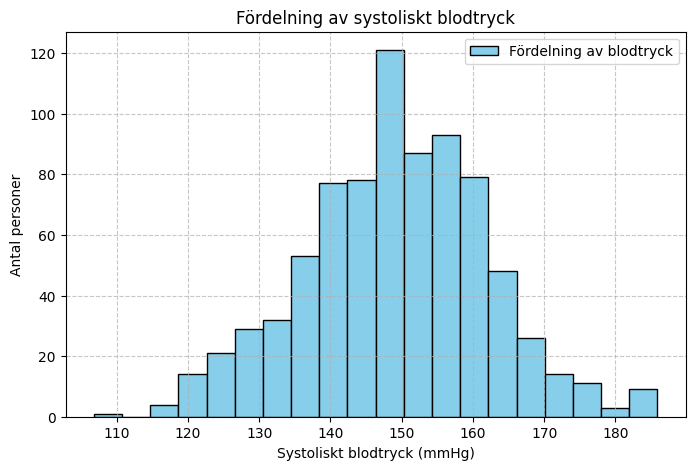

In [6]:
analyzer.plot_bp_histogram()

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
model, r2 = analyzer.fit_bp_regression(["age", "weight"])
print("Intercept:", model.intercept_)
print("Koefficienter:", model.coef_)
print("R^2", r2)

Intercept: 109.49908144566373
Koefficienter: [0.53892763 0.17765752]
R^2 0.4052560814611623


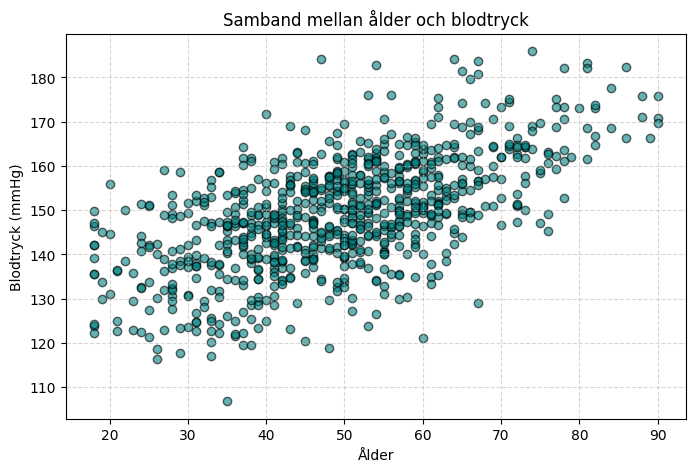

In [9]:
analyzer.plot_age_vs_bp()

### Här undersöker jag sambandet mellan ålder och systoliskt blodtryck. Varje punkt är en person i datasättet. Jag ser att:
- det finns en trend : *blodtrycket ökar oftast med åldern*
- unga deltagare (20-40 år) har blodtryck runt **120-145 mmHG**
- äldre personer (60+ år) ligger oftare högre, ibland över **170 mmHG**
- spridningen inom varje åldersgrupp är ganska stor, vilket måste betyda att åldern inte förklarar variationen i blodtrycket
- grafen stödjer faktiskt min resultat från regretionsmodellen där jag fick fram **R² värde på ca 0.40**, alltså ungefär 40% av variationen kan förklaras av ålder och vikt.

Slutsats: **Äldre personer trenderar att ha högre blodtryck, men ålder är inte den enda faktorn som påverkar.**